In [1]:
from typing import Tuple, Optional, Callable


import jax.numpy as jnp
import jax
from flax.struct import dataclass
from mtp.splines.akima import poly_akima, poly_interpolation
from mtp.splines.bsplines import compute_b_spline_matrix

In [2]:
mean = jnp.arange(10) * 10
spline = jnp.arange(10)
cov = jnp.arange(10) * 0.1    
last_a_idx = 2
planning_horizon = 10
sigma_max = 0.2


# roll all arrays accroding to which actions we already took
mean = jnp.roll(mean, shift=-last_a_idx, axis=0)
cov = jnp.roll(cov, shift=-last_a_idx, axis=0)
spline = jnp.roll(spline, shift=-last_a_idx, axis=0)

last_idx = planning_horizon - last_a_idx
mask = jnp.arange(planning_horizon) < last_idx
mean = jnp.where(mask, mean, jnp.ones_like(mean) * jnp.take(mean, last_idx-1, 0))
cov = jnp.where(mask, cov, sigma_max)
spline = jnp.where(mask, spline, jnp.ones_like(spline) * jnp.take(spline, last_idx-1, 0))

print(jnp.take(mean, last_idx, 0))
print("mask:", mask)
print("mean:", mean)
print("cov:", cov)
print("spline:", spline)

90
mask: [ True  True  True  True  True  True  True  True False False]
mean: [20 30 40 50 60 70 80 90 90 90]
cov: [0.2        0.3        0.4        0.5        0.6        0.7
 0.8        0.90000004 0.2        0.2       ]
spline: [2 3 4 5 6 7 8 9 9 9]


In [3]:
def start_clamped_knot_vector(num_ctrl_points, degree):
    # First p+1 knots are the same
    n_knots = num_ctrl_points + degree + 1
    start = jnp.zeros(degree + 1, dtype=float)
    end = jnp.ones(degree + 1, dtype=float) 
    # The rest increase uniformly
    nbr_rest = n_knots - 2 * (degree + 1) + 1
    rest = (jnp.arange(1,nbr_rest, dtype=float)) * (1.0 / (nbr_rest))  # Normalize to [0, 1]
    return jnp.concatenate([start, rest, end])



def interpolate_path(path: jax.Array, num_points: int) -> jax.Array:
    start, goal = path[:-1], path[1:]
    linspace = lambda x, y, n: jnp.linspace(x, y, n + 1)[:-1]
    return jax.vmap(linspace, in_axes=(0, 0, None))(start, goal, num_points).reshape(-1, path.shape[-1])

    
num_samples = 16
planning_horizon = 10
nu = 2
M = 3
N = 32
u_min = -1.0
u_max = 1.0
degree = 2
beta = 0.5
interpolation = 'bspline'

aknots = jnp.linspace(1, M, M)
bknots = start_clamped_knot_vector((M + 1), degree)
bmat = compute_b_spline_matrix(bknots, degree, planning_horizon)



@dataclass
class AnMTPParams:
    """Policy parameters for model-predictive path integral control.
    """
    rng: jax.Array
    mean: jax.Array = None    # (T, nu)
    cov: jax.Array = None     # (T, nu)
    spline: jax.Array = None  # (T, nu)
    last_a_idx: int = None


def sample_controls(params: AnMTPParams
    ) -> Tuple[jax.Array, AnMTPParams]:
    """Sample a control sequence."""
    rng = params.rng
    
    # roll all arrays accroding to which actions we already took
    mean = jnp.roll(params.mean, shift=-params.last_a_idx, axis=0)
    cov = jnp.roll(params.cov, shift=-params.last_a_idx, axis=0)
    spline = jnp.roll(params.spline, shift=-params.last_a_idx, axis=0)

    last_idx = planning_horizon - params.last_a_idx
    mask = jnp.arange(planning_horizon) < last_idx
    

    
    mean = jnp.where(mask[..., None], mean, jnp.ones_like(mean) * jnp.take(mean, last_idx-1, 0))
    cov = jnp.where(mask[..., None], cov, jnp.ones_like(cov) * jnp.take(cov, last_idx-1, 0))
    spline = jnp.where(mask[..., None], spline, jnp.ones_like(spline) * jnp.take(spline, last_idx-1, 0))

    # The previous spline is included as a sample
    controls = params.spline[None, ...]
    
    #------------------------
    
    # Sample the control points for the MTP
    rng, sample_rng = jax.random.split(rng)
    control_points = jax.random.uniform(
        sample_rng,
        (
            M,
            N,
            nu,
        ),
        minval=u_min,
        maxval=u_max,
    )
    # sample points from the graph
    rng, sample_rng = jax.random.split(rng)
    layer_indices = jax.random.randint(rng, (num_samples-1, M), 0, N - 1)
    def get_path(path_id: jax.Array) -> jax.Array:
        return control_points[jnp.arange(M), path_id]
    control_points = jax.vmap(get_path)(layer_indices)
    
    # add last_a_index of spline as first control point
    # b spline matrix is for one additional control point for this
    # !! Double Check
    init_sample = jnp.repeat(params.spline[params.last_a_idx][None, None, :], num_samples-1, axis=0)
    print(init_sample)
    control_points = jnp.concatenate(
        [init_sample, control_points], axis=1
    )
    
    # interpolate the control points
    if interpolation == 'akima':
        A = jax.vmap(poly_akima, in_axes=(None, 0))(aknots, control_points) # (batch, M - 1, 4, nu)
        num_interp = planning_horizon // (M - 1)
        remain = planning_horizon - num_interp * (M - 1)
        mtp_controls = poly_interpolation(A, num_interp)
        remain_controls = jnp.repeat(control_points[:, -1, None], remain, axis=1)
        mtp_controls = jnp.concatenate([mtp_controls, remain_controls], axis=1)
    elif interpolation == 'bspline':
        # TODO this has to incorporate the last taken control as a first point + interpolate
        mtp_controls = jnp.einsum("bmd,hm->bhd", control_points, bmat)
    elif interpolation == 'linear':
        num_interp = planning_horizon // (M - 1)
        remain = planning_horizon - num_interp * (M - 1)
        mtp_controls = jax.vmap(interpolate_path, in_axes=(0, None))(control_points, num_interp)
        remain_controls = jnp.repeat(control_points[:, -1, None], remain, axis=1)
        mtp_controls = jnp.concatenate([mtp_controls, remain_controls], axis=1)
    else:
        raise ValueError(f"Invalid sampling strategy: {interpolation}")
   


    # Sample mppi_samples control sequences
    def colorize_time_series(noise, alpha=2.0, remove_dc=True, eps=1e-8):
        """
        noise: (B, T, D) white ~ N(0,1)
        Returns colored noise with approx unit variance per (B,D) trajectory.
        alpha=0 -> white, 1 -> pink (1/f), 2 -> brown (1/f^2)
        """
        B, T, D = noise.shape

        # reshape to (B*D, T) to FFT each series independently
        x = noise.reshape(B * D, T)

        # FFT -> apply magnitude shaping -> IFFT
        Xf = jnp.fft.rfft(x, axis=-1)                           # (B*D, T_r)
        freqs = jnp.fft.rfftfreq(T)                             # (T_r,)
        H = (1.0 / jnp.maximum(freqs, eps)) ** (alpha / 2.0)    # magnitude shaping
        if remove_dc:
            H = H.at[0].set(0.0)
        Yf = Xf * H[None, :]                                    # broadcast
        y = jnp.fft.irfft(Yf, n=T, axis=-1)                     # (B*D, T)

        # de-mean and unit-std per series (robust for finite T)
        y = y - y.mean(axis=-1, keepdims=True)
        y = y / (y.std(axis=-1, keepdims=True) + eps)

        return y.reshape(B, T, D)
    rng, sample_rng = jax.random.split(rng)
    noise = jax.random.normal(
        sample_rng,
        (
            num_samples - 1,
            planning_horizon,
            nu,
        ),
    )
    mppi_controls = params.mean + params.cov * colorize_time_series(noise)
    
    # print shapes
    print("mppi_controls shape:", mppi_controls.shape)
    print("controls shape:", mtp_controls.shape)

    # create boolean masks for random selection
    total_samples = num_samples 
    mtp_samples = int(num_samples * beta)
    mppi_samples = num_samples - mtp_samples - 1  # last spline is part of samples

    rng, mask_rng = jax.random.split(rng)
    all_indices = jnp.arange(total_samples)
    mtp_indices = jax.random.choice(mask_rng, all_indices, (mtp_samples,), replace=False)
    remaining_indices = jnp.setdiff1d(all_indices, mtp_indices)
    mppi_indices = jax.random.choice(mask_rng, remaining_indices, (mppi_samples,), replace=False)

    mtp_mask = jnp.zeros(total_samples-1, dtype=bool).at[mtp_indices].set(True)
    mppi_mask = jnp.zeros(total_samples-1, dtype=bool).at[mppi_indices].set(True)

    # Zero out values in each group and add for final result
    # controls[:total_samples] contains all but the last spline
    mtp_selected = mtp_controls * mtp_mask[:, None, None]
    mppi_selected = mppi_controls * mppi_mask[:, None, None]
    #final_result = mtp_selected + mppi_selected

    #controls = jnp.concatenate([controls, final_result], axis=0)

    return controls, mppi_selected, mtp_selected, params.replace(rng=rng, 
                                                                    mean=mean, 
                                                                    cov=cov, 
                                                                    spline=spline)


In [4]:
# init 
beta2 = 0.4
def action_annealed(t):
    return jnp.exp(-(planning_horizon - t) * 2 / (beta2 * planning_horizon))

annealed_cov = jnp.ones((planning_horizon, nu)) * jnp.array([action_annealed(t) for t in range(planning_horizon)])[...,None]
print("annealed_cov:", annealed_cov)

test = AnMTPParams(
    rng=jax.random.PRNGKey(0),
    mean=jnp.ones((planning_horizon, nu)) * (jnp.arange(planning_horizon)/planning_horizon)[..., None],
    cov=annealed_cov,
    spline=jnp.ones((planning_horizon, nu)) * (jnp.arange(planning_horizon)/planning_horizon)[..., None],
    last_a_idx=2
)

controls, mppi_selected, mtp_selected, test = sample_controls(test)


annealed_cov: [[0.00673795 0.00673795]
 [0.011109   0.011109  ]
 [0.01831564 0.01831564]
 [0.03019738 0.03019738]
 [0.04978707 0.04978707]
 [0.082085   0.082085  ]
 [0.13533528 0.13533528]
 [0.22313017 0.22313017]
 [0.36787948 0.36787948]
 [0.60653067 0.60653067]]
[[[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]

 [[0.2 0.2]]]
mppi_controls shape: (15, 10, 2)
controls shape: (15, 10, 2)


(1, 10, 2)


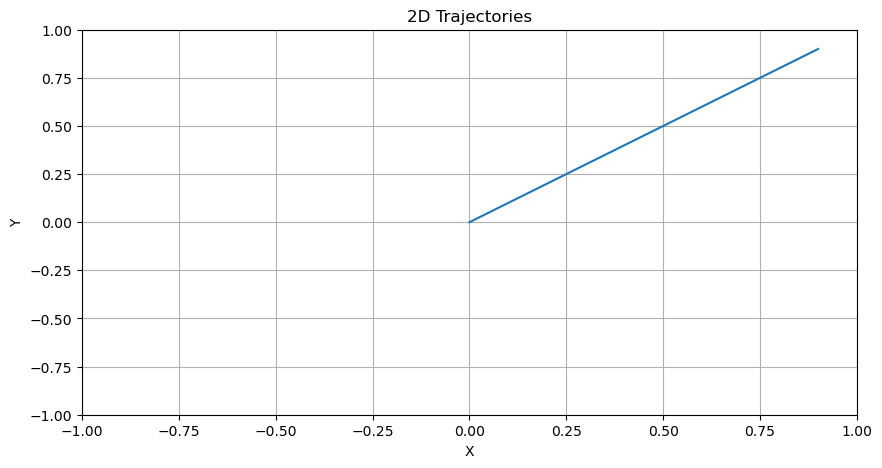

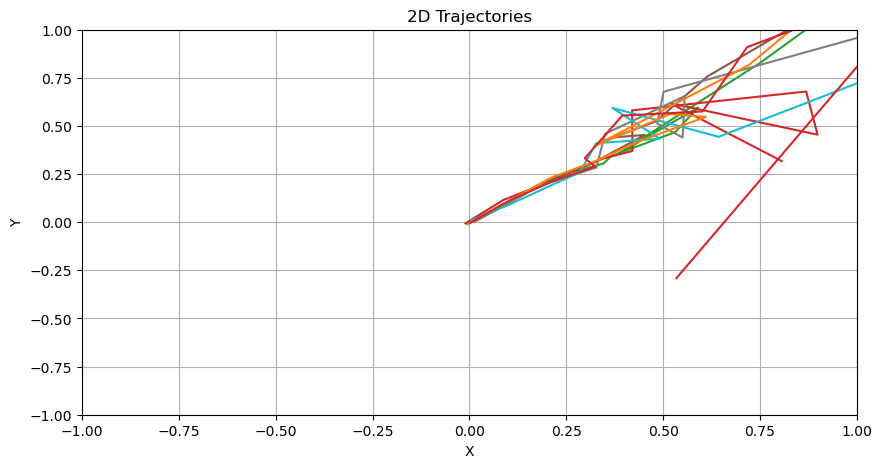

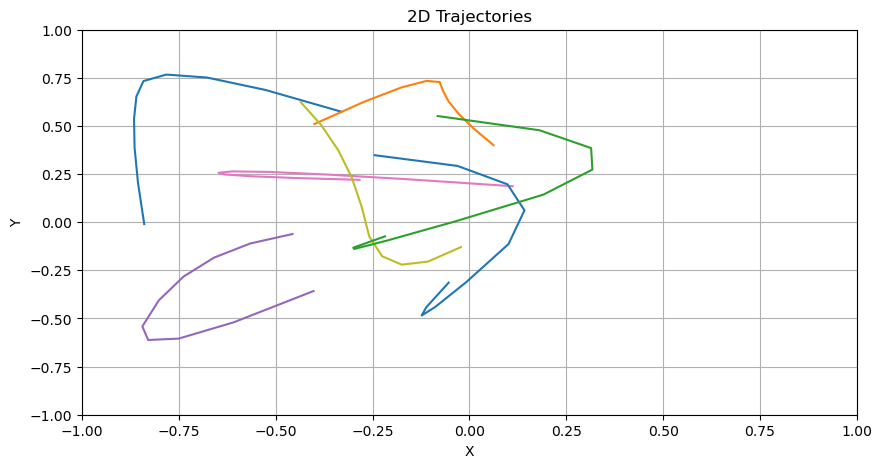

In [5]:
print(controls.shape)
# plot 2d trajectories based on samples
import matplotlib.pyplot as plt

def plot_trajectories(controls):
    plt.figure(figsize=(10, 5))
    for i in range(controls.shape[0]):
        plt.plot(controls[i, :, 0], controls[i, :, 1], label=f"Sample {i}")
    plt.xlabel("X")
    # set limits
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.ylabel("Y")
    plt.title("2D Trajectories")
    plt.grid()
    plt.show()

plot_trajectories(controls)
plot_trajectories(mppi_selected)
plot_trajectories(mtp_selected)